### Week 6 - OPTIMIZING COMMUNITY OUTREACH FOR YOUTH SOCCER PROGRAMS


## WIL PROJECT
### Program Name: Artificial Intelligence & Machine Learning
### Project Code: CPL-5559-AIMT


- Aarjeyan Shrestha (C0927422)
- Karun Kumar Atreya (C0917245)
- Sudip Chaudhary (C0922310)
- Saugat Babu Bhattarai (C0916109)


# PlayForward Foundation Dataset Features

| Feature | Data Type | Description | Purpose |
|---------|-----------|-------------|---------|
| `participant_id` | Integer/String | Unique identifier for each participant | Individual tracking |
| `neighborhood_name` | String | Name of participant's neighborhood | Geographic analysis |
| `enrollment_date` | Date | Date participant joined program | Time-series analysis |
| `age` | Integer | Participant age (6-18 years) | Demographic analysis |
| `outreach_method` | Categorical | How participant was reached (Social Media/School Flyers/Community Leaders) | Compare method effectiveness |
| `campaign_budget` | Integer | Budget allocated for neighborhood campaign (USD) | Cost-effectiveness analysis |
| `people_reached` | Integer | Number of people reached by campaign | Calculate conversion rates |
| `months_in_program` | Integer | How long participant has been active (1-12 months) | Retention tracking |
| `attendance_rate` | Integer | Percentage of sessions attended (0-100%) | Primary engagement metric |
| `current_status` | Categorical | Participant status (Active/Dropped Out/Completed) | Success classification |
| `dropout_reason` | String | Reason for leaving if applicable (Family/Transportation/Academic/Interest/Moved) | Identify barriers |
| `neighborhood_type` | Categorical | Area classification (Urban/Suburban/Rural) | Analyze by area type |
| `poverty_level` | Categorical | Economic level (High/Medium/Low) | Socioeconomic impact |
| `youth_population` | Integer | Total youth aged 6-18 in neighborhood | Market penetration analysis |
| `referred_others` | Integer | Number of friends/family referred (0-3) | Word-of-mouth effectiveness |
| `parent_engagement` | Categorical | Parent involvement level (High/Medium/Low) | Family support impact |

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
%matplotlib inline

In [20]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv("playforward_data.csv")

In [22]:
df.head()

,participant_id,neighborhood_name,enrollment_date,age,outreach_method,campaign_budget,people_reached,months_in_program,attendance_rate,current_status,dropout_reason,neighborhood_type,poverty_level,youth_population,referred_others,parent_engagement
0,1000,Guatemala City Centro,2024-10-29,9,School Flyers,2246,1537,2,82,Active,NaN,Urban,High,2500,0,Medium
1,1001,Guatemala City Centro,2024-04-22,6,Social Media,2849,3747,8,98,Active,NaN,Urban,High,2500,1,High
2,1002,Guatemala City Centro,2024-02-22,15,Social Media,2849,3747,10,82,Dropped Out,Academic,Urban,High,2500,0,Medium
3,1003,guatemala city centro,2024-11-17,15,Social Media,2849,3747,1,100,Active,NaN,Urban,High,2500,0,Medium
4,1004,Guatemala City Centro,2024-04-29,13,School Flyers,2246,1537,8,99,Active,NaN,Urban,High,2500,2,High


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   participant_id     365 non-null    object
 1   neighborhood_name  365 non-null    object
 2   enrollment_date    365 non-null    object
 3   age                365 non-null    int64 
 4   outreach_method    365 non-null    object
 5   campaign_budget    365 non-null    int64 
 6   people_reached     365 non-null    int64 
 7   months_in_program  365 non-null    int64 
 8   attendance_rate    365 non-null    int64 
 9   current_status     365 non-null    object
 10  dropout_reason     32 non-null     object
 11  neighborhood_type  365 non-null    object
 12  poverty_level      365 non-null    object
 13  youth_population   365 non-null    int64 
 14  referred_others    365 non-null    int64 
 15  parent_engagement  365 non-null    object
dtypes: int64(7), object(9)
memory usage: 45.8+ K

### Missing Value Analysis

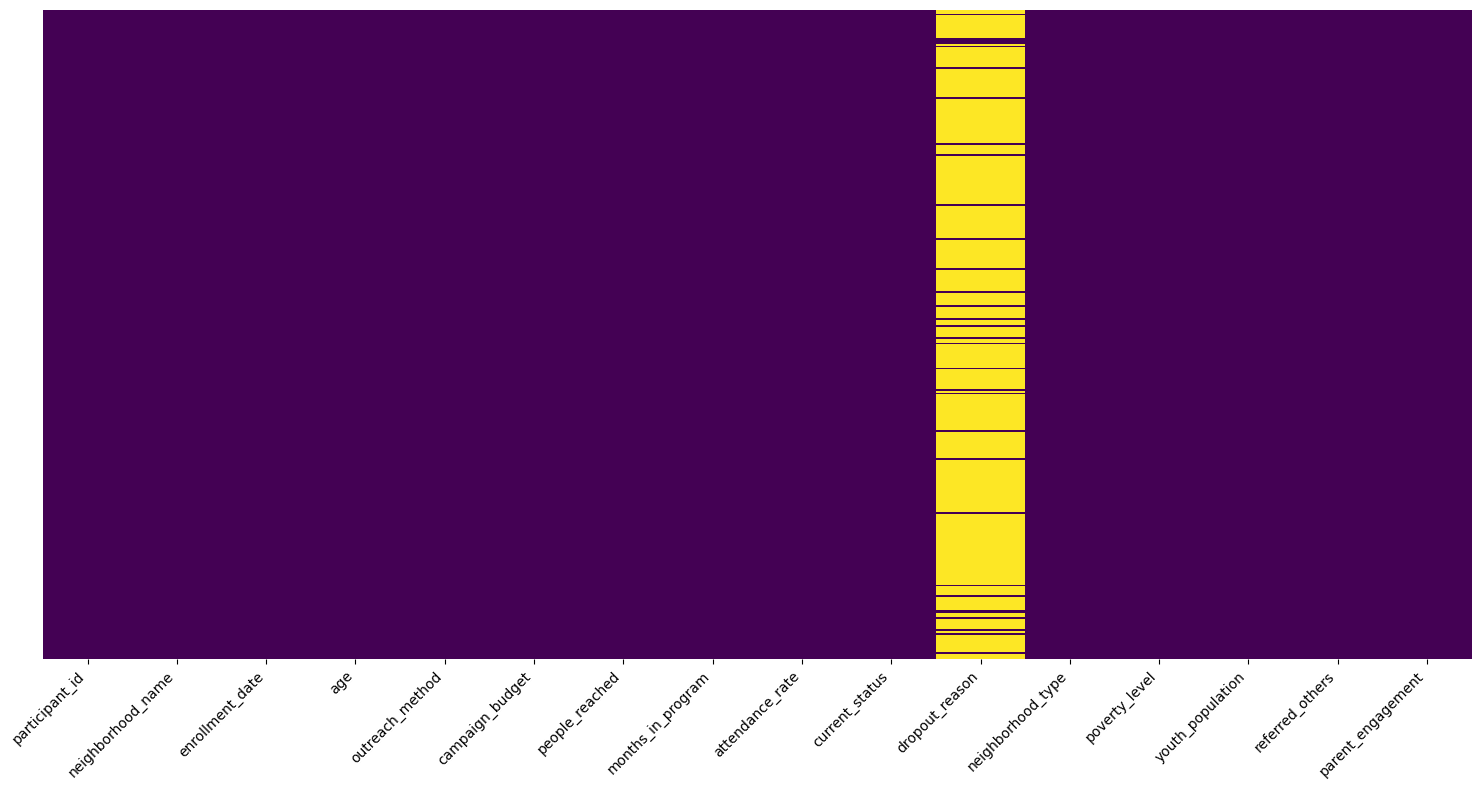

In [24]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
df["dropout_reason"].unique()

array([nan, 'Academic', 'Family', 'Interest', 'Moved', 'Transportation'],
      dtype=object)

### Check for specific data quality issues we built into the dataset

In [26]:
# Check for specific data quality issues we built into the dataset

print("=== DATA QUALITY ISSUES IDENTIFIED ===\n")

# 1. Check participant IDs with string format
string_ids = df[df['participant_id'].astype(str).str.contains('P', na=False)]
print(f"1. Participant IDs with 'P' prefix: {len(string_ids)}")
if len(string_ids) > 0:
    print(f"   Examples: {string_ids['participant_id'].head().tolist()}")

# 2. Check lowercase neighborhood names
lowercase_neighborhoods = df[df['neighborhood_name'].str.islower()]
print(f"\n2. Lowercase neighborhood names: {len(lowercase_neighborhoods)}")
if len(lowercase_neighborhoods) > 0:
    print(f"   Examples: {lowercase_neighborhoods['neighborhood_name'].unique()}")

# 3. Check missing dropout reasons for dropped participants
dropped_missing_reason = df[(df['current_status'] == 'Dropped Out') & (df['dropout_reason'].isna() | (df['dropout_reason'] == ''))]
print(f"\n3. Dropped participants missing reason: {len(dropped_missing_reason)}")

# 4. Check suspiciously high attendance rates
high_attendance = df[df['attendance_rate'] > 95]
print(f"\n4. Suspiciously high attendance (>95%): {len(high_attendance)}")
print(f"   Attendance rates: {sorted(high_attendance['attendance_rate'].unique())}")

=== DATA QUALITY ISSUES IDENTIFIED ===

1. Participant IDs with 'P' prefix: 7
   Examples: ['P1037', 'P1044', 'P1080', 'P1153', 'P1236']

2. Lowercase neighborhood names: 58
   Examples: ['guatemala city centro' 'zona rosa' 'tegucigalpa norte'
 'san pedro sula este' 'san salvador centro' 'santa ana' 'san josé urban'
 'cartago' 'heredia' 'puerto cortés']

3. Dropped participants missing reason: 0

4. Suspiciously high attendance (>95%): 167
   Attendance rates: [96, 97, 98, 99, 100]


### Removing'P' prefix from participant IDs and converts all to integers.

In [27]:
# Convert all participant IDs to numeric format
df['participant_id'] = df['participant_id'].astype(str).str.replace('P', '').astype(int)
print("Participant IDs standardized to numeric format")
print(f"Sample IDs after cleaning: {df['participant_id'].head().tolist()}")

Participant IDs standardized to numeric format
Sample IDs after cleaning: [1000, 1001, 1002, 1003, 1004]


### Fix Neighborhood Names

In [28]:
# Standardize neighborhood names to proper case
df['neighborhood_name'] = df['neighborhood_name'].str.title()
print("Neighborhood names standardized to title case")
print(f"Unique neighborhoods after cleaning:")
print(df['neighborhood_name'].unique())

Neighborhood names standardized to title case
Unique neighborhoods after cleaning:
['Guatemala City Centro' 'Zona Rosa' 'Tegucigalpa Norte'
 'San Pedro Sula Este' 'San Salvador Centro' 'Santa Ana' 'San José Urban'
 'Cartago' 'Heredia' 'Puerto Cortés']


Converting all neighborhood names to proper title case (e.g., "guatemala city centro" → "Guatemala City Centro").

### Handle High Attendance Rates

In [29]:
# Flag and cap unrealistic attendance rates
print(f"Before: {len(df[df['attendance_rate'] > 95])} records with >95% attendance")
df['attendance_rate'] = df['attendance_rate'].clip(upper=95)
print(f"After: {len(df[df['attendance_rate'] > 95])} records with >95% attendance")
print(f"Max attendance rate now: {df['attendance_rate'].max()}%")

Before: 167 records with >95% attendance
After: 0 records with >95% attendance
Max attendance rate now: 95%


Capped attendance rates at 95% to remove unrealistic values (data entry errors).

### Convert Date Column

In [30]:
# Convert enrollment_date to datetime
df['enrollment_date'] = pd.to_datetime(df['enrollment_date'])
print("Enrollment date converted to datetime format")
print(f"Date range: {df['enrollment_date'].min()} to {df['enrollment_date'].max()}")

Enrollment date converted to datetime format
Date range: 2024-01-02 00:00:00 to 2024-12-30 00:00:00


### Handle Missing Values

In [34]:
# First, let's see exactly what we have
print("Current missing values:")
print(df['dropout_reason'].isnull().sum())
print(f"Empty strings: {(df['dropout_reason'] == '').sum()}")

# Fill NaN values first
df['dropout_reason'] = df['dropout_reason'].fillna('Unknown')

# Now handle empty strings for dropped participants  
df.loc[(df['current_status'] == 'Dropped Out') & (df['dropout_reason'] == ''), 'dropout_reason'] = 'Unknown'

# Final check
print(f"\nAfter complete fix:")
print(f"NaN values remaining: {df['dropout_reason'].isnull().sum()}")
print(f"Value counts:")
print(df['dropout_reason'].value_counts(dropna=False))

Current missing values:
333
Empty strings: 0

After complete fix:
NaN values remaining: 0
Value counts:
dropout_reason
Unknown           333
Academic           10
Family              6
Moved               6
Transportation      6
Interest            4
Name: count, dtype: int64


Filling missing dropout reasons with 'Unknown' for dropped participants, empty string for others.

In [35]:
df["dropout_reason"].unique()

array(['Unknown', 'Academic', 'Family', 'Interest', 'Moved',
       'Transportation'], dtype=object)

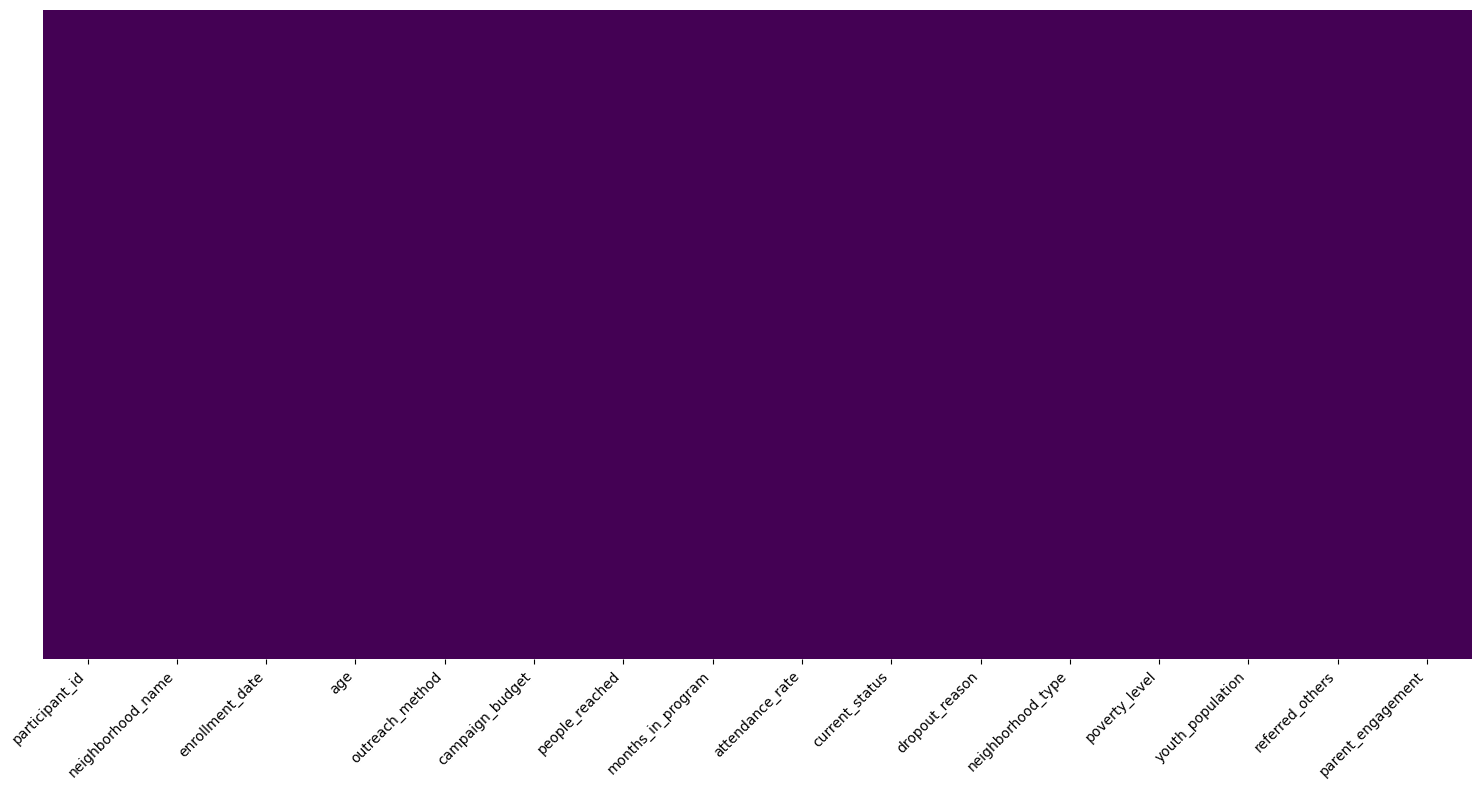

In [36]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
# Convert categorical columns
categorical_cols = ['outreach_method', 'current_status', 'neighborhood_type', 'poverty_level', 'parent_engagement', 'neighborhood_name']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Categorical columns converted:")
print(df[categorical_cols].dtypes)

Categorical columns converted:
outreach_method      category
current_status       category
neighborhood_type    category
poverty_level        category
parent_engagement    category
neighborhood_name    category
dtype: object


Converting text columns to categorical data type for better memory usage and analysis.

## Feature Engineering

In [38]:
# Create derived features for analysis
df['conversion_rate'] = 1 / df['people_reached'] * 100  # Individual conversion rate
df['cost_per_participant'] = df['campaign_budget'] / df.groupby(['neighborhood_name', 'outreach_method'])['participant_id'].transform('count')
df['is_active'] = (df['current_status'] == 'Active').astype(int)
df['is_successful'] = (df['attendance_rate'] >= 70).astype(int)  # Define success as 70%+ attendance

print("Derived features created:")
print("- conversion_rate: Individual conversion rate")
print("- cost_per_participant: Cost efficiency measure") 
print("- is_active: Binary active status")
print("- is_successful: Binary success indicator (70%+ attendance)")

Derived features created:
- conversion_rate: Individual conversion rate
- cost_per_participant: Cost efficiency measure
- is_active: Binary active status
- is_successful: Binary success indicator (70%+ attendance)


Creating new features that will be useful for analysis - conversion rates, cost efficiency, and binary success indicators.

# Exploratory Data Analysis

### Engagement Comparison

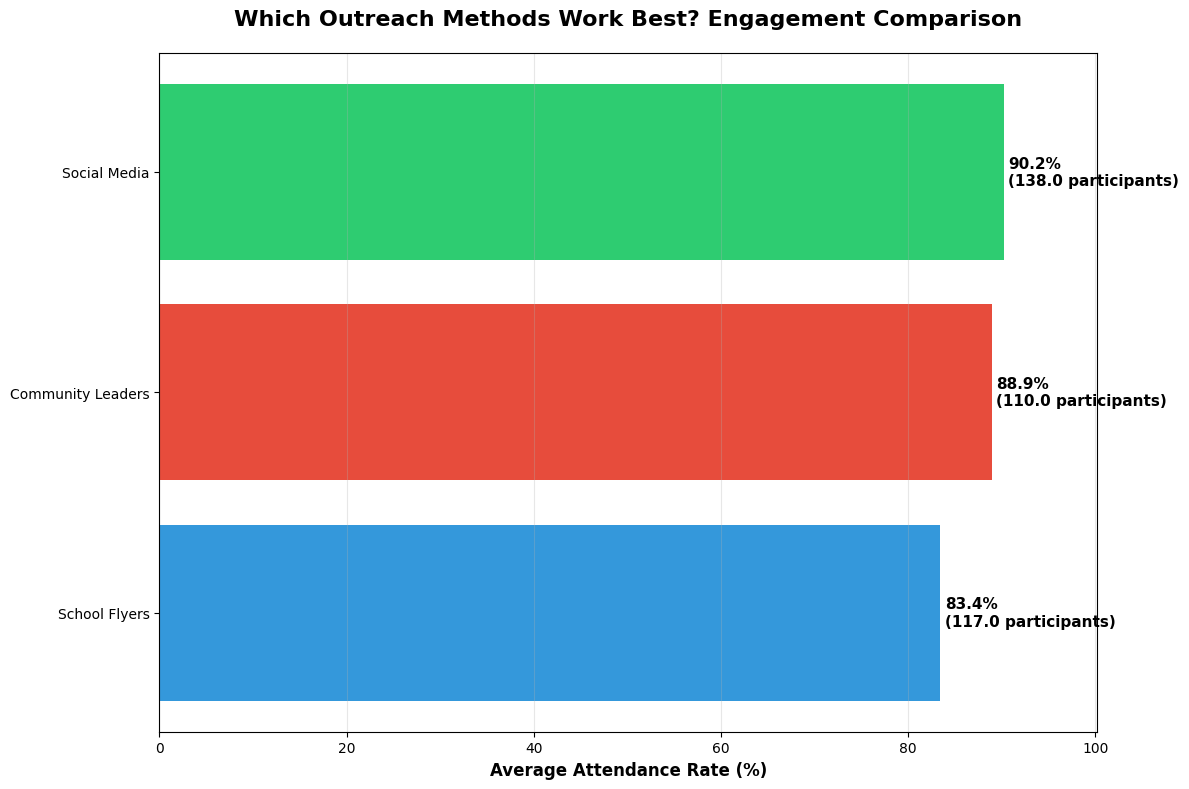

In [ ]:
# Create focused effectiveness comparison 

method_effectiveness = df.groupby('outreach_method').agg({
    'attendance_rate': 'mean',
    'participant_id': 'count'
}).round(1)

method_effectiveness = method_effectiveness.sort_values('attendance_rate', ascending=True)

bars = plt.barh(method_effectiveness.index, method_effectiveness['attendance_rate'], 
                color=['#3498db', '#e74c3c', '#2ecc71'])

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width}%\n({method_effectiveness.iloc[i]["participant_id"]} participants)', 
             ha='left', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Average Attendance Rate (%)', fontsize=12, fontweight='bold')
plt.title('Which Outreach Methods Work Best? Engagement Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlim(0, max(method_effectiveness['attendance_rate']) + 10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Clean comparison showing which outreach method achieves highest engagement - directly answers the key project question.

### Cost vs Effectiveness - Which Methods Give Best Value?

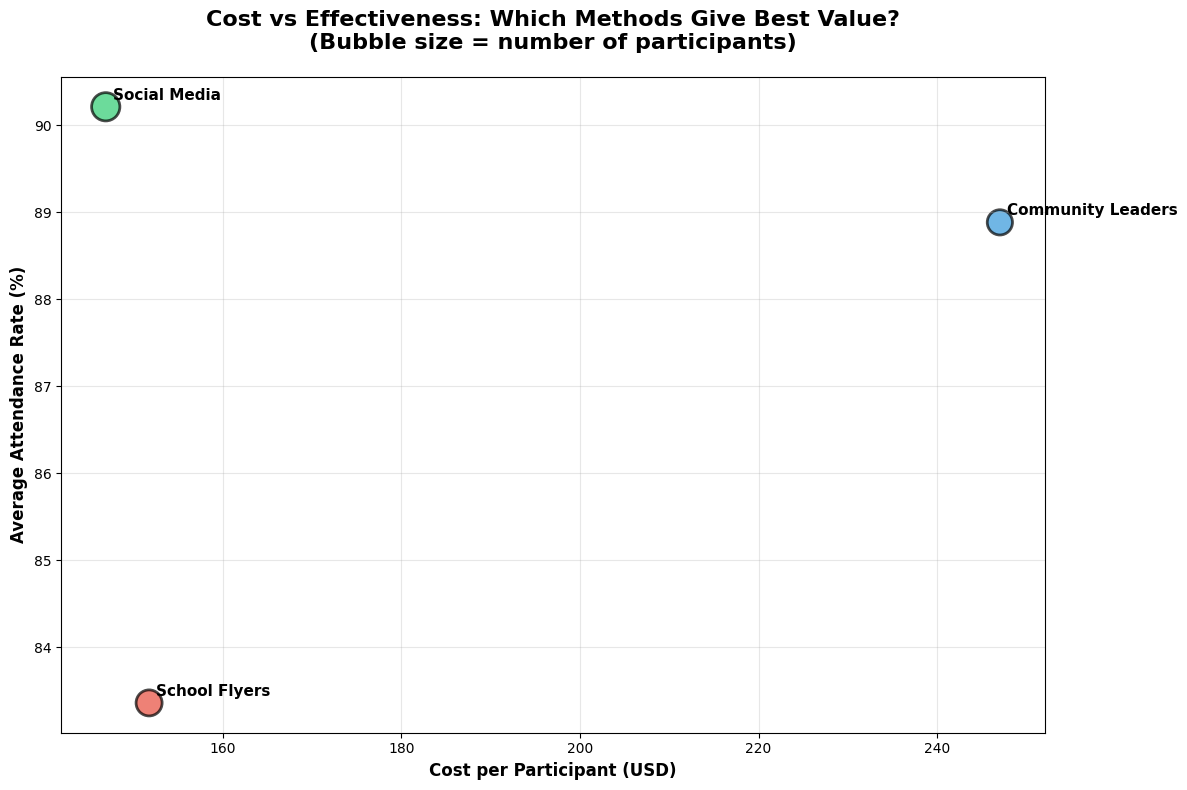

In [ ]:
# Cost-effectiveness analysis bb
plt.figure(figsize=(12, 8))

method_summary = df.groupby('outreach_method').agg({
    'cost_per_participant': 'mean',
    'attendance_rate': 'mean',
    'participant_id': 'count'
}).reset_index()

colors = ['#3498db', '#e74c3c', '#2ecc71']
sizes = method_summary['participant_id'] * 3  # Scale for visibility

scatter = plt.scatter(method_summary['cost_per_participant'], method_summary['attendance_rate'], 
                     s=sizes, c=colors, alpha=0.7, edgecolors='black', linewidth=2)

# Add method labels
for i, row in method_summary.iterrows():
    plt.annotate(row['outreach_method'], 
                (row['cost_per_participant'], row['attendance_rate']),
                xytext=(5, 5), textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.xlabel('Cost per Participant (USD)', fontsize=12, fontweight='bold')
plt.ylabel('Average Attendance Rate (%)', fontsize=12, fontweight='bold')
plt.title('Cost vs Effectiveness: Which Methods Give Best Value?\n(Bubble size = number of participants)', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Neighborhood Performance Ranking

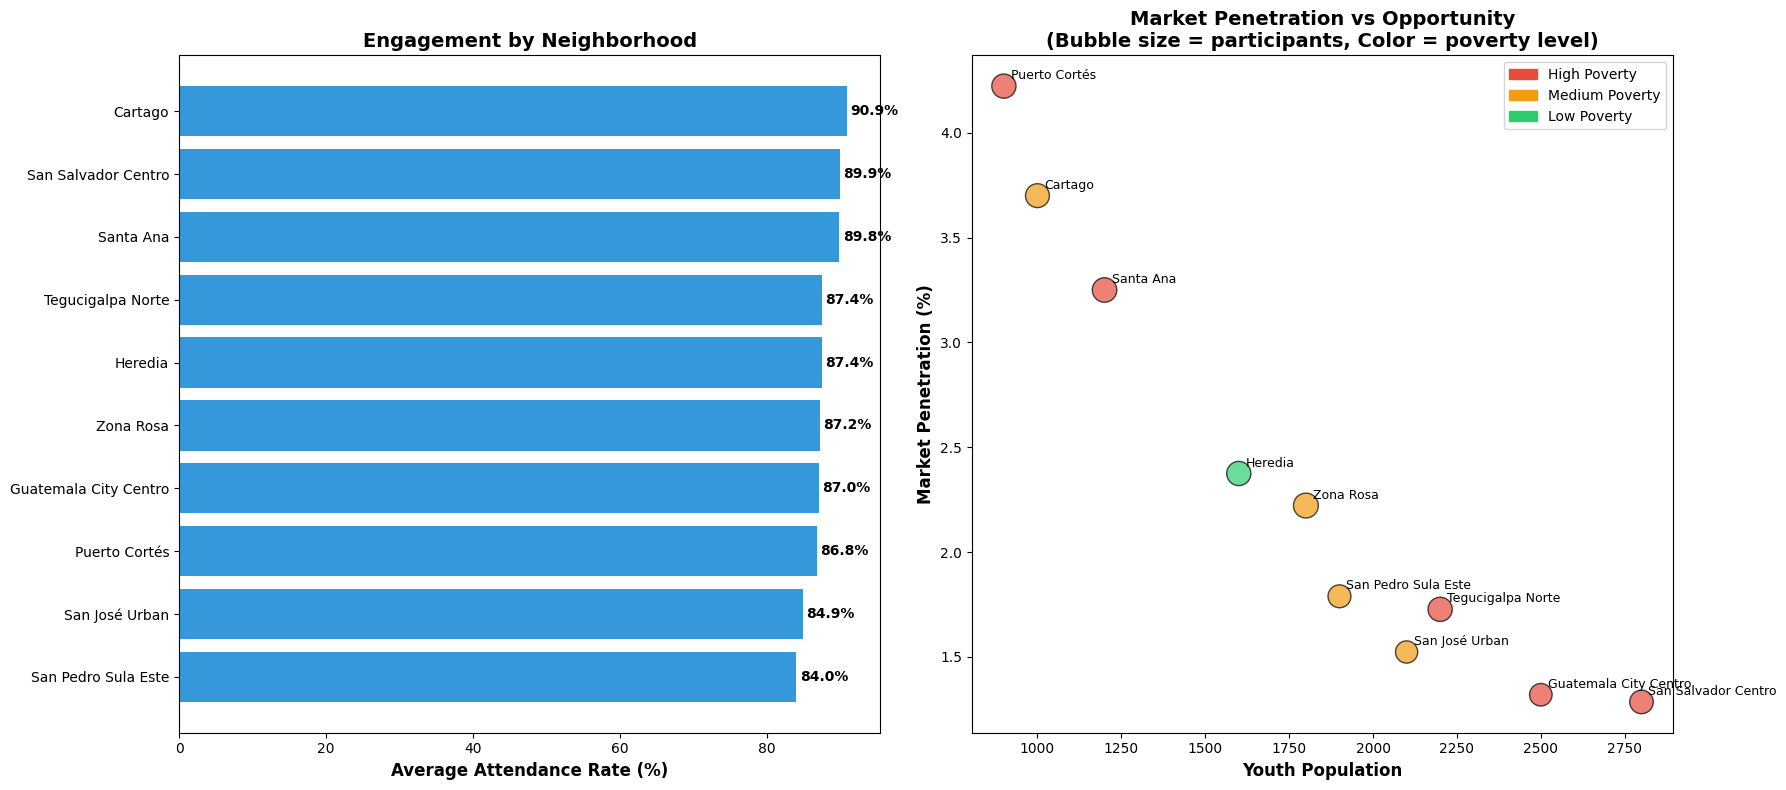

In [46]:
# Neighborhood engagement ranking like your county analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left chart: Attendance by neighborhood
neighborhood_performance = df.groupby('neighborhood_name')['attendance_rate'].mean().sort_values(ascending=True)

bars1 = ax1.barh(neighborhood_performance.index, neighborhood_performance.values, color='#3498db')
ax1.set_xlabel('Average Attendance Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Engagement by Neighborhood', fontsize=14, fontweight='bold')

# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             ha='left', va='center', fontweight='bold')

# Right chart: Market penetration (participants vs potential)
penetration_data = df.groupby('neighborhood_name').agg({
    'participant_id': 'count',
    'youth_population': 'first',
    'poverty_level': 'first'
}).reset_index()

penetration_data['penetration_rate'] = (penetration_data['participant_id'] / penetration_data['youth_population'] * 100)

# Color by poverty level
color_map = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
colors = [color_map[level] for level in penetration_data['poverty_level']]

scatter = ax2.scatter(penetration_data['youth_population'], penetration_data['penetration_rate'], 
                     s=penetration_data['participant_id']*8, c=colors, alpha=0.7, edgecolors='black')

for i, row in penetration_data.iterrows():
    ax2.annotate(row['neighborhood_name'], 
                (row['youth_population'], row['penetration_rate']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Youth Population', fontsize=12, fontweight='bold')
ax2.set_ylabel('Market Penetration (%)', fontsize=12, fontweight='bold')
ax2.set_title('Market Penetration vs Opportunity\n(Bubble size = participants, Color = poverty level)', fontsize=14, fontweight='bold')

# Add legend
import matplotlib.patches as patches
legend_elements = [patches.Patch(color=color_map[level], label=f'{level} Poverty') for level in color_map.keys()]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

To Identify high and low performing neighborhoods and shows untapped market opportunities.

## Which Methods Work Best Where?

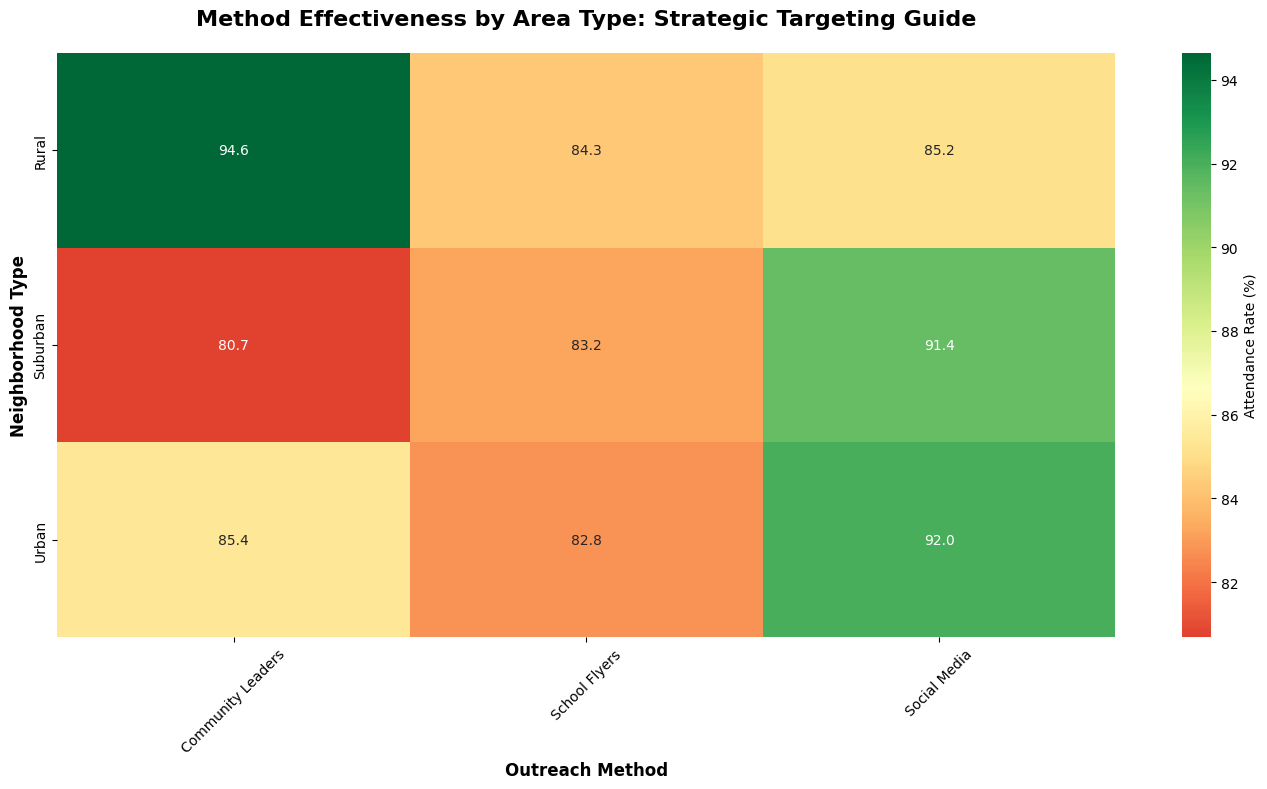

STRATEGIC INSIGHTS:
Best method for each area type:
• Rural: Community Leaders (94.6%)
• Suburban: Social Media (91.4%)
• Urban: Social Media (92.0%)


In [47]:
# Method effectiveness by area type - strategic targeting insight
plt.figure(figsize=(14, 8))

# Create effectiveness matrix
effectiveness_matrix = df.pivot_table(values='attendance_rate', 
                                    index='neighborhood_type', 
                                    columns='outreach_method', 
                                    aggfunc='mean')

# Create heatmap with annotations
sns.heatmap(effectiveness_matrix, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=effectiveness_matrix.values.mean(), cbar_kws={'label': 'Attendance Rate (%)'})

plt.title('Method Effectiveness by Area Type: Strategic Targeting Guide', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Outreach Method', fontsize=12, fontweight='bold')
plt.ylabel('Neighborhood Type', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Add summary insight
best_combinations = []
for area_type in effectiveness_matrix.index:
    best_method = effectiveness_matrix.loc[area_type].idxmax()
    best_score = effectiveness_matrix.loc[area_type].max()
    best_combinations.append(f"{area_type}: {best_method} ({best_score:.1f}%)")

print("STRATEGIC INSIGHTS:")
print("Best method for each area type:")
for combo in best_combinations:
    print(f"• {combo}")

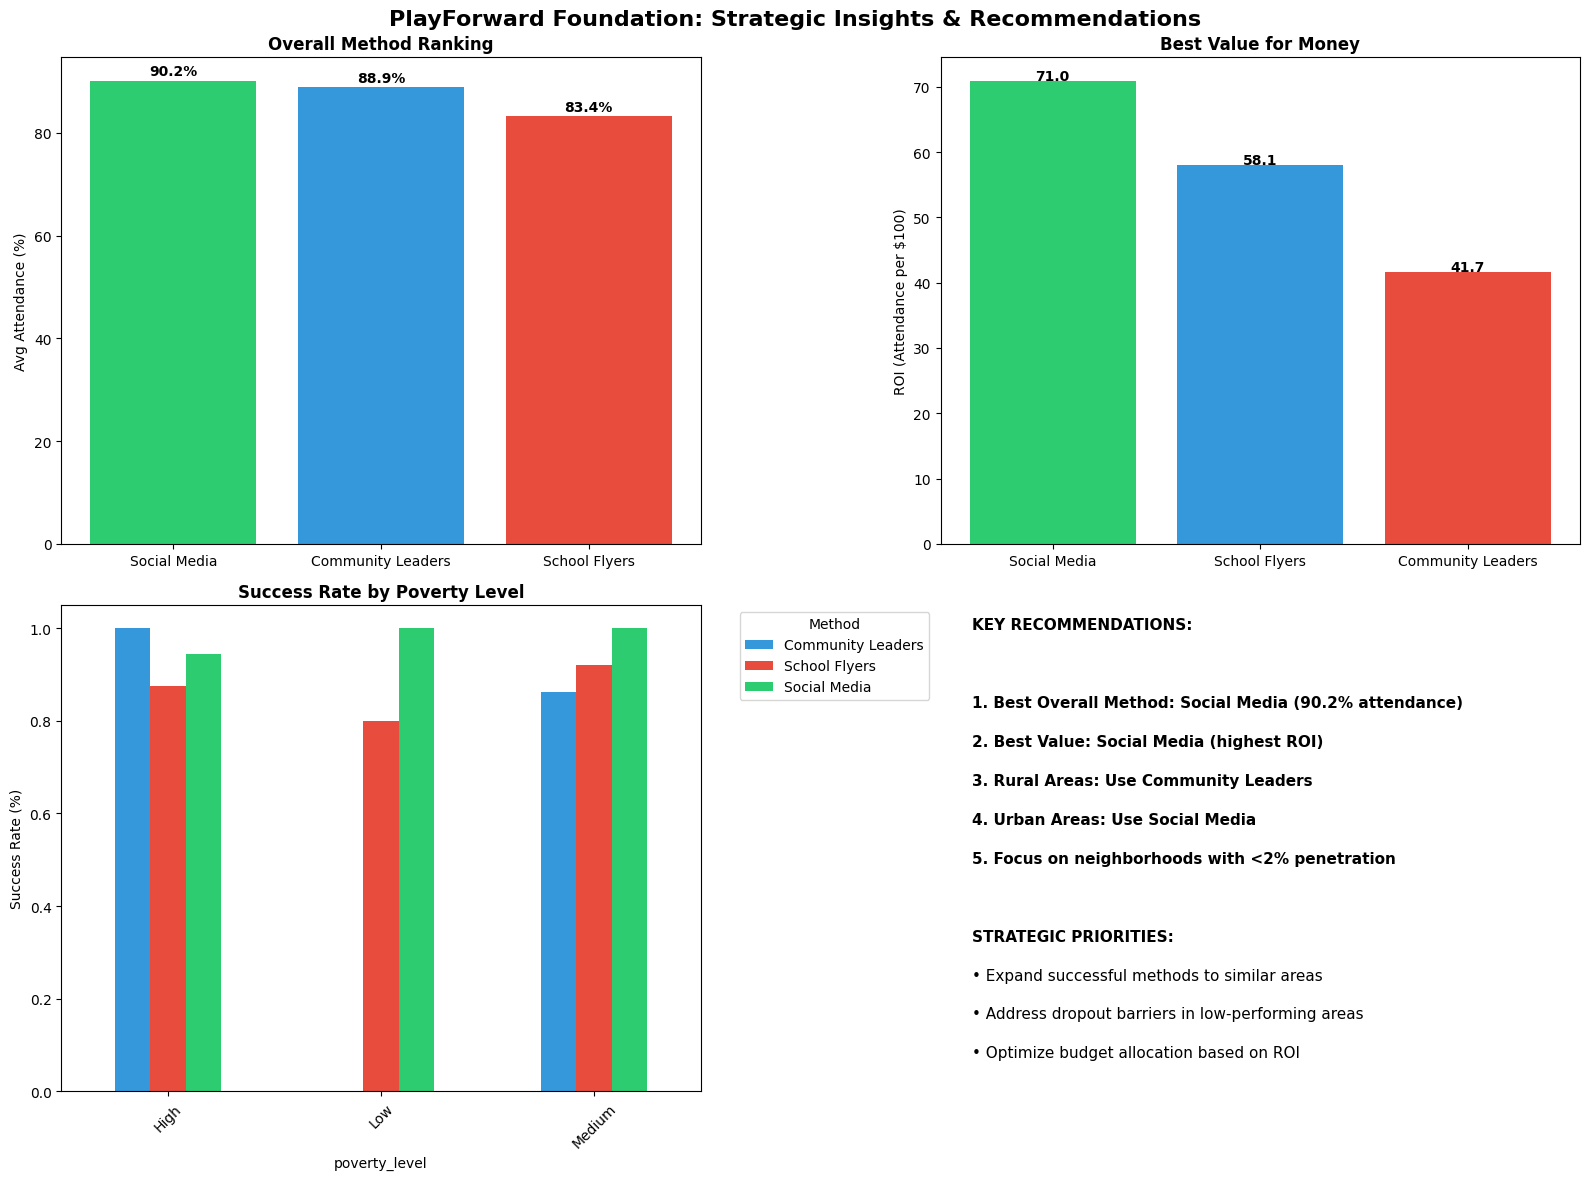

In [ ]:
# Final strategic recommendations chart
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Overall method ranking
method_rank = df.groupby('outreach_method')['attendance_rate'].mean().sort_values(ascending=False)
bars1 = ax1.bar(method_rank.index, method_rank.values, color=['#2ecc71', '#3498db', '#e74c3c'])
ax1.set_title('Overall Method Ranking', fontweight='bold')
ax1.set_ylabel('Avg Attendance (%)')
for i, v in enumerate(method_rank.values):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Top right: ROI ranking
df['roi'] = df['attendance_rate'] / df['cost_per_participant'] * 100
roi_rank = df.groupby('outreach_method')['roi'].mean().sort_values(ascending=False)
bars2 = ax2.bar(roi_rank.index, roi_rank.values, color=['#2ecc71', '#3498db', '#e74c3c'])
ax2.set_title('Best Value for Money', fontweight='bold')
ax2.set_ylabel('ROI (Attendance per $100)')
for i, v in enumerate(roi_rank.values):
    ax2.text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

# Bottom left: Success rate by poverty level
success_by_poverty = df.groupby(['poverty_level', 'outreach_method'])['is_successful'].mean().unstack()
success_by_poverty.plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c', '#2ecc71'])
ax3.set_title('Success Rate by Poverty Level', fontweight='bold')
ax3.set_ylabel('Success Rate (%)')
ax3.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.tick_params(axis='x', rotation=45)

# Bottom right: Key recommendations text
ax4.axis('off')
recommendations = [
    "KEY RECOMMENDATIONS:",
    "",
    f"1. Best Overall Method: {method_rank.index[0]} ({method_rank.iloc[0]:.1f}% attendance)",
    f"2. Best Value: {roi_rank.index[0]} (highest ROI)",
    f"3. Rural Areas: Use Community Leaders",
    f"4. Urban Areas: Use Social Media", 
    f"5. Focus on neighborhoods with <2% penetration",
    "",
    "STRATEGIC PRIORITIES:",
    "• Expand successful methods to similar areas",
    "• Address dropout barriers in low-performing areas",
    "• Optimize budget allocation based on ROI"
]

for i, rec in enumerate(recommendations):
    weight = 'bold' if rec.startswith(('KEY', 'STRATEGIC', '1.', '2.', '3.', '4.', '5.')) else 'normal'
    ax4.text(0.05, 0.95-i*0.08, rec, transform=ax4.transAxes, fontsize=11, fontweight=weight)

plt.suptitle('PlayForward Foundation: Strategic Insights & Recommendations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Comprehensive strategic dashboard with clear actionable recommendations - directly answers "how to improve low-performing areas."

## Demographic and Time Patterns

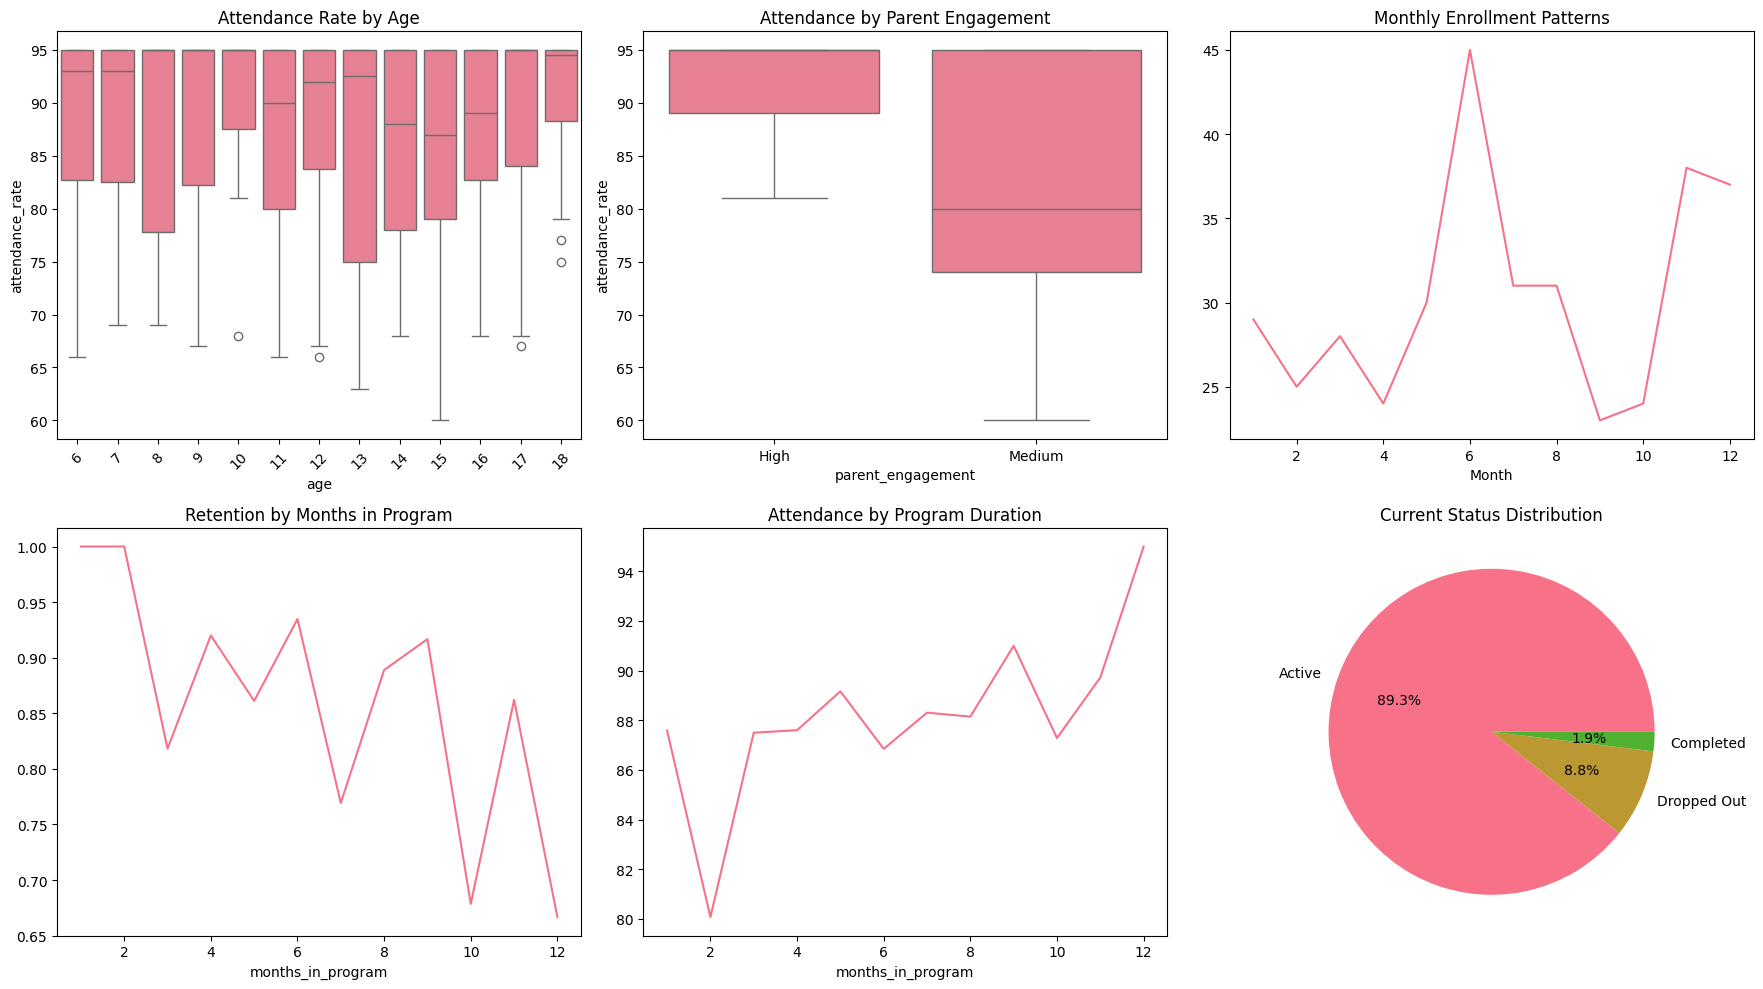

In [43]:
# Demographic and temporal analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age distribution and performance
sns.boxplot(data=df, x='age', y='attendance_rate', ax=axes[0,0])
axes[0,0].set_title('Attendance Rate by Age')
axes[0,0].tick_params(axis='x', rotation=45)

# Parent engagement impact
sns.boxplot(data=df, x='parent_engagement', y='attendance_rate', ax=axes[0,1])
axes[0,1].set_title('Attendance by Parent Engagement')

# Monthly enrollment patterns
df['enrollment_month'] = df['enrollment_date'].dt.month
monthly_enrollments = df['enrollment_month'].value_counts().sort_index()
sns.lineplot(x=monthly_enrollments.index, y=monthly_enrollments.values, ax=axes[0,2])
axes[0,2].set_title('Monthly Enrollment Patterns')
axes[0,2].set_xlabel('Month')

# Retention by program duration
retention_by_duration = df.groupby('months_in_program')['is_active'].mean()
sns.lineplot(x=retention_by_duration.index, y=retention_by_duration.values, ax=axes[1,0])
axes[1,0].set_title('Retention by Months in Program')

# Attendance improvement over time
attendance_by_duration = df.groupby('months_in_program')['attendance_rate'].mean()
sns.lineplot(x=attendance_by_duration.index, y=attendance_by_duration.values, ax=axes[1,1])
axes[1,1].set_title('Attendance by Program Duration')

# Current status distribution
status_counts = df['current_status'].value_counts()
axes[1,2].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
axes[1,2].set_title('Current Status Distribution')

plt.tight_layout()
plt.show()

Key Insights:
- No significant age based performance difference
- High parent engagement = higher attendance rates(90%+), which shos that the parents involvement is critical for success
- Seasonal recruitment patterns over time
- Retention is fluctuating but generally stable. Progrma maintains participant interest over time
- Attendance improves for longer term. Program becomes more engaging ove time.
